In [35]:
import pandas as pd

df = pd.read_excel("Downloads/Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [37]:
df.shape

(7043, 33)

In [39]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [41]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [43]:
churn_rate = (1869 / 7043) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


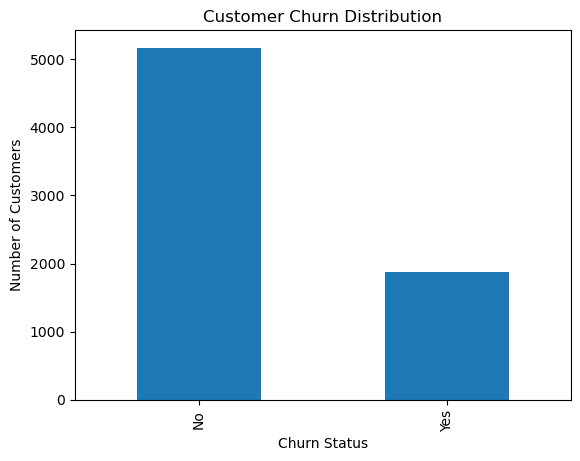

In [45]:
import matplotlib.pyplot as plt

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [47]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [49]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [51]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [53]:
df["Tenure Months"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

In [55]:
df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

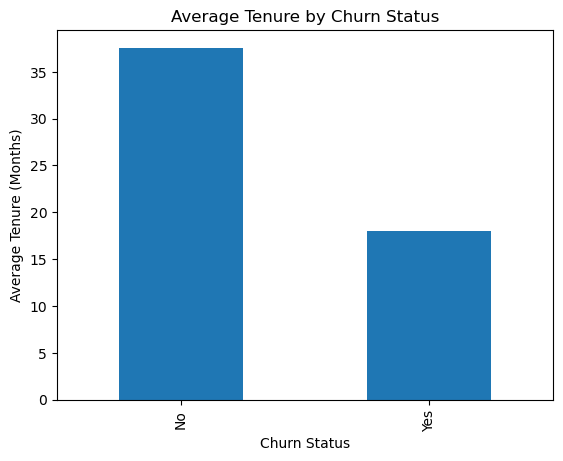

In [58]:
import matplotlib.pyplot as plt

df.groupby("Churn Label")["Tenure Months"].mean().plot(kind="bar")

plt.title("Average Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")

plt.show()

In [60]:
df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

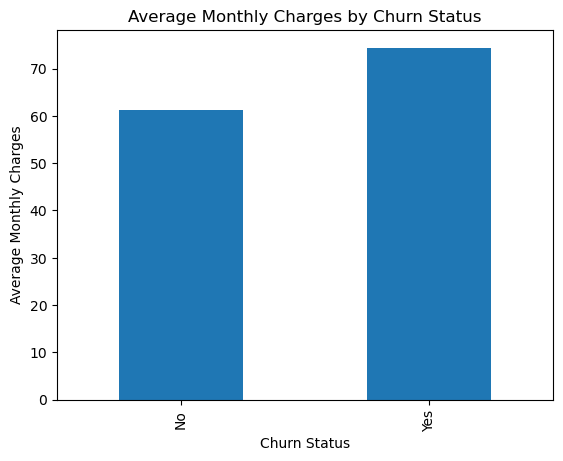

In [62]:
df.groupby("Churn Label")["Monthly Charges"].mean().plot(kind="bar")

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")

plt.show()

In [64]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [66]:
df["Churn Reason"].value_counts().head(10)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

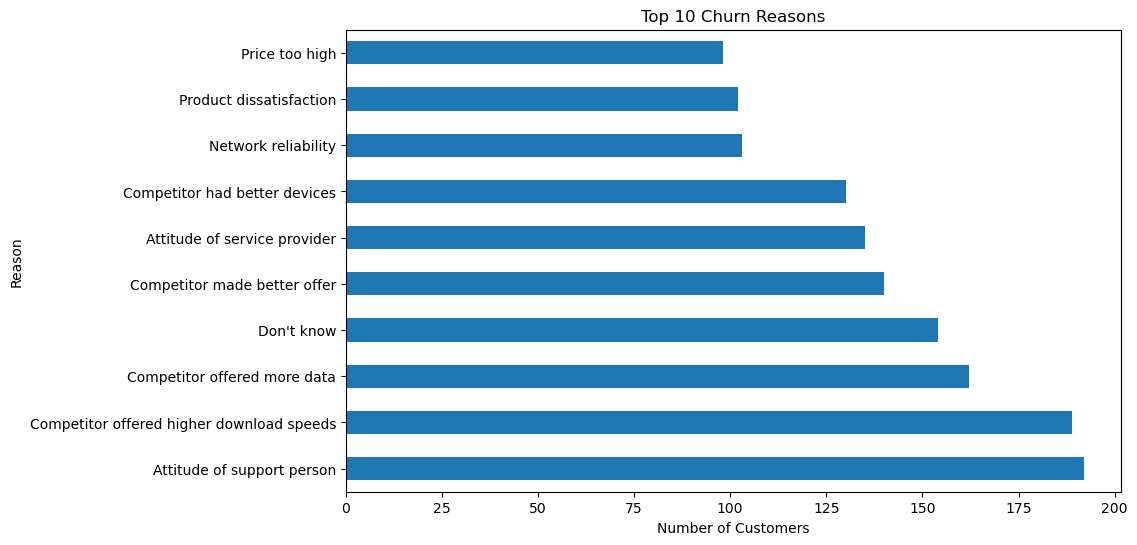

In [68]:
df["Churn Reason"].value_counts().head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Customers")
plt.ylabel("Reason")

plt.show()

In [70]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


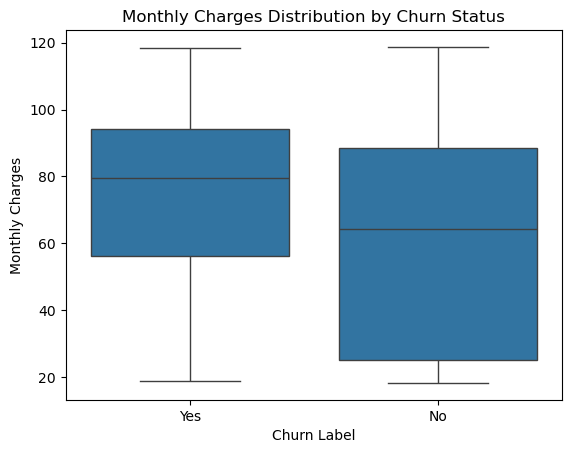

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="Churn Label",
    y="Monthly Charges",
    data=df
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.show()

In [74]:
df_ml = df.drop([
    "CustomerID",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
], axis=1)

In [76]:
df_ml.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


In [80]:
df_encoded = pd.get_dummies(
    df_ml,
    drop_first=True
)

In [82]:
df_encoded.shape

(7043, 6561)

In [84]:
for col in df_ml.columns:
    print(col, ":", df_ml[col].nunique())

Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Tenure Months : 73
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Monthly Charges : 1585
Total Charges : 6531
Churn Value : 2
CLTV : 3438


In [86]:
df_ml.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Value            int64
CLTV                   int64
dtype: object

In [88]:
df_ml["Monthly Charges"] = pd.to_numeric(
    df_ml["Monthly Charges"],
    errors="coerce"
)

df_ml["Total Charges"] = pd.to_numeric(
    df_ml["Total Charges"],
    errors="coerce"
)

df_ml["CLTV"] = pd.to_numeric(
    df_ml["CLTV"],
    errors="coerce"
)

In [90]:
df_ml.dtypes

Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Value            int64
CLTV                   int64
dtype: object

In [92]:
df_encoded = pd.get_dummies(
    df_ml,
    drop_first=True
)

In [94]:
df_encoded.shape

(7043, 32)

In [96]:
X = df_encoded.drop("Churn Value", axis=1)

y = df_encoded["Churn Value"]

In [98]:
X.shape

(7043, 31)

In [100]:
y.shape

(7043,)

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 31)
(1409, 31)
(5634,)
(1409,)


In [106]:
from sklearn.ensemble import RandomForestClassifier

In [108]:
model = RandomForestClassifier(
    random_state=42
)

In [110]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [112]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [114]:
y_pred = model.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7984386089425124


In [118]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7984386089425124


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

In [120]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.69      0.53      0.60       400

    accuracy                           0.80      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [122]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10)

Tenure Months                      0.159323
Total Charges                      0.151260
Monthly Charges                    0.138317
CLTV                               0.124493
Internet Service_Fiber optic       0.036239
Payment Method_Electronic check    0.034326
Dependents_Yes                     0.032473
Contract_Two year                  0.032427
Gender_Male                        0.023295
Online Security_Yes                0.022296
dtype: float64

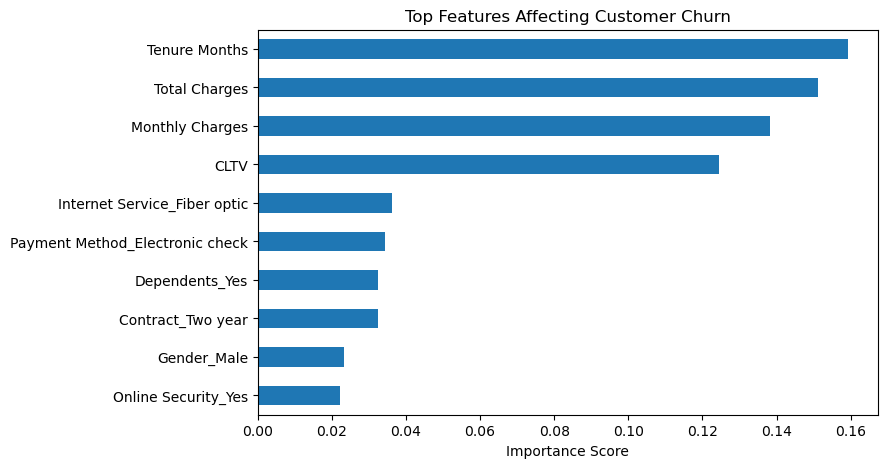

In [124]:
importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Features Affecting Customer Churn")
plt.xlabel("Importance Score")
plt.show()